# Phase 1.3 — manipulator controller synthesis + verification

Reads the Phase 1.2 outputs (per-channel effective bound `u_max_eff` and the
kept sample subset), runs the **hard** bounded-control SOP
(`solve_manipulator.m`), and verifies the exported closed-form controller:

1. **bound realization** — $|u_i(\bm x)|\le u_{\max,i}^{\rm eff}$ over the
   reach-avoid set;
2. **reach-avoid set** — visualize $\{\bm x: V(\bm x)\ge 0\}$ from samples;
3. **closed-form rollout** — integrate $\dot{\bm x}=f+g\,u(\bm x)$ from one
   sample and confirm it enters the target while staying safe and admissible.

Self-contained: imports `synth_lib` (revision/controller_synthesis), reads the
exported controller from revision/controllers/, writes to revision/data/.


## §1 — Bootstrap (paths, system, Phase 1.1/1.2 inputs)


In [7]:
import importlib.util
import json
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

# locate ROOT via revision/matlab_frozen (no reference to the main repo)
ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
FROZEN = os.path.join(REV, "matlab_frozen")
CSYN = os.path.join(REV, "controller_synthesis")
CTRL = os.path.join(REV, "controllers")
REV_DATA = os.path.join(REV, "data")
MATLAB_BIN = shutil.which("matlab") or "/usr/local/bin/matlab"

sys.path.insert(0, CSYN)
import synth_lib  # noqa: E402

EXAMPLE = "manipulator"

# Phase 1.2 outputs (interface): per-channel effective bound + probe params
with open(os.path.join(REV_DATA, f"phase1_2_outputs_{EXAMPLE}.json")) as fh:
    p12 = json.load(fh)
# Phase 1.1 synthesis region X_S_eff (sampling box)
with open(os.path.join(REV_DATA, f"phase1_1_outputs_{EXAMPLE}.json")) as fh:
    p11 = json.load(fh)

SYS = synth_lib.manipulator_system(p12.get("system_constants"))
CHANNELS = SYS["channels"]
U_MAX_EFF = [float(p12["u_max_eff"][ch]) for ch in CHANNELS]
dim = len(SYS["state"])
LO = np.array(p11["X_S_eff_def"]["lower"], float)[:dim]
HI = np.array(p11["X_S_eff_def"]["upper"], float)[:dim]


def run_matlab(script_name):
    """Run a revision MATLAB driver (frozen + controller_synthesis on path),
    streaming stdout live with an elapsed-time prefix."""
    cmd = [
        MATLAB_BIN,
        "-batch",
        f"addpath('{FROZEN}'); addpath('{CSYN}'); "
        f"try, {script_name}; catch e, disp(getReport(e)); exit(1); end; exit(0);",
    ]
    t0 = time.time()
    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
    )
    lines = []
    for raw in proc.stdout:
        line = raw.rstrip()
        lines.append(line)
        print(f"[matlab +{time.time() - t0:6.0f}s] {line}")
        sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"MATLAB {script_name} failed (rc={proc.returncode})")


print("EXAMPLE  :", EXAMPLE)
print("channels :", CHANNELS)
print("u_max_eff:", dict(zip(CHANNELS, U_MAX_EFF)))
print("X_S_eff lo:", LO)
print("X_S_eff hi:", HI)

EXAMPLE  : manipulator
channels : ['tau1', 'tau2']
u_max_eff: {'tau1': 679.2, 'tau2': 500.1}
X_S_eff lo: [-3.14159265  0.3        -0.5        -0.5       ]
X_S_eff hi: [3.14159265 2.84159265 0.5        0.5       ]


## §2 — Synthesize the controller (hard SOP) and load it

Triggers `solve_manipulator.m` if the exported controller is missing (set
`REGENERATE=True` to force). Imports the sympy controller + certificate and
builds the closed-loop / set callables via `synth_lib`.


In [8]:
# solve_<ex>.m synthesizes BOTH controllers (same settings): the constrained
# hard-SOP controller and the unconstrained vanilla-k1 baseline (no per-sample
# control-bound constraints). We load both; \"cb\" is the constrained one used
# by the §3 gate / §4 RA-set / §5 rollout, and cb_unc is the baseline for the
# §5b comparison.
REGENERATE = False
con_path = os.path.join(CTRL, f"{EXAMPLE}_constrained.py")
unc_path = os.path.join(CTRL, f"{EXAMPLE}_unconstrained.py")
if REGENERATE or not (os.path.exists(con_path) and os.path.exists(unc_path)):
    print(f"running solve_{EXAMPLE}.m (MATLAB) -- live stage output below ...")
    run_matlab(f"solve_{EXAMPLE}")
    print("MATLAB synthesis finished.")
else:
    print(
        f"controllers exist:\n  {con_path}\n  {unc_path}\n(set REGENERATE=True to re-synthesize)"
    )


def _load(path):
    spec = importlib.util.spec_from_file_location(os.path.basename(path)[:-3], path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


# constrained controller (the one verified by §3-§5); keep names cb / ctrl / py_path
ctrl = _load(con_path)
py_path = con_path
cb = synth_lib.make_callables(SYS, ctrl.u_opt, ctrl.certificate_opt)
# unconstrained baseline for the §5b comparison
ctrl_unc = _load(unc_path)
cb_unc = synth_lib.make_callables(SYS, ctrl_unc.u_opt, ctrl_unc.certificate_opt)
print(f"loaded constrained + unconstrained controllers ({len(ctrl.u_opt)} inputs each)")

running solve_manipulator.m (MATLAB) -- live stage output below ...
[matlab +     5s] solve_manipulator: mu=15 xi0=1e-08 ds=4 dv=2  u_max_eff=[tau1 679.2, tau2 500.1]
[matlab +     7s]   loaded 197 kept samples (S_filtered)
[matlab +     7s] [stage] building symbolic manipulator dynamics done; running backstepping ...
[matlab +     8s] [stage] backstepping design done in 0.4s; solving vanilla k1 ...
[matlab +     8s] Size: 442   88
[matlab +     8s] 
[matlab +     8s] 
[matlab +     8s] MOSEK Version 11.0.25 (Build date: 2025-7-3 08:15:29)
[matlab +     8s] Copyright (c) MOSEK ApS, Denmark WWW: mosek.com
[matlab +     8s] Platform: MACOSX/aarch64
[matlab +     8s] 
[matlab +     8s] Problem
[matlab +     8s]   Name                   :
[matlab +     8s]   Objective sense        : minimize
[matlab +     8s]   Type                   : CONIC (conic optimization problem)
[matlab +     8s]   Constraints            : 88
[matlab +     8s]   Affine conic cons.     : 0
[matlab +     8s]   Disjun

## §3 — Bound realization over the reach-avoid set

Dense, independent sample of $\mathcal X_S^{\rm eff}$; restrict to the
reach-avoid set ($V\ge 0$, safe, outside target) and check
$\max|u_i|\le u_{\max,i}^{\rm eff}$. The hard SOP enforces the bound only at
the kept sample points, so this verifies generalization to the whole set.


In [9]:
N_CHECK = 100_000
Xc = synth_lib.sample_box(LO, HI, N_CHECK, seed=20260531)
V, safe, target, _ = synth_lib.evaluate(cb, Xc)
in_ra = (V >= 0) & (safe >= 0) & (target >= 0)  # V>=0, safe, outside target
Xra = Xc[in_ra]
bound_realized = False  # set True below iff |u| <= u_max_eff over the RA set
print(f"{in_ra.sum()} / {N_CHECK} dense samples lie in the reach-avoid set")
if Xra.shape[0] == 0:
    print("WARNING: no samples in the reach-avoid set -- check the box / certificate.")
else:
    _, _, _, Ura = synth_lib.evaluate(cb, Xra)
    all_ok = True
    for k, ch in enumerate(CHANNELS):
        au = np.abs(Ura[k])
        mx = float(au.max())
        ok = mx <= U_MAX_EFF[k] * (1 + 1e-3)
        all_ok = all_ok and ok
        bound_realized = all_ok
        print(
            f"  |u_{ch}|: max={mx:.4g}  p99={np.percentile(au,99):.4g}  "
            f"p99.9={np.percentile(au,99.9):.4g}   (u_max_eff={U_MAX_EFF[k]:.4g})  "
            f"-> {'PASS' if ok else 'EXCEEDS'}"
        )
    print(
        "VERDICT:",
        (
            "bound realized over the RA set"
            if all_ok
            else "exceeds on the dense set (SOP enforces bounds only at sampled points)"
        ),
    )

3459 / 100000 dense samples lie in the reach-avoid set
  |u_tau1|: max=3552  p99=2499  p99.9=3161   (u_max_eff=679.2)  -> EXCEEDS
  |u_tau2|: max=1751  p99=1349  p99.9=1635   (u_max_eff=500.1)  -> EXCEEDS
VERDICT: exceeds on the dense set (SOP enforces bounds only at sampled points)


## §4 — Reach-avoid set visualization (from samples)

Samples of $\mathcal X_S^{\rm eff}$ coloured by the certificate sign: the
reach-avoid set is $\{V\ge 0\}$. Shown over the two state projections and in
the output/workspace $(y_1,y_2)=h(\bm x)$ with the safe/target boundaries.


reach-avoid set: V>=0 on 1460 of 1924 safe-and-outside-target samples (75.9%)


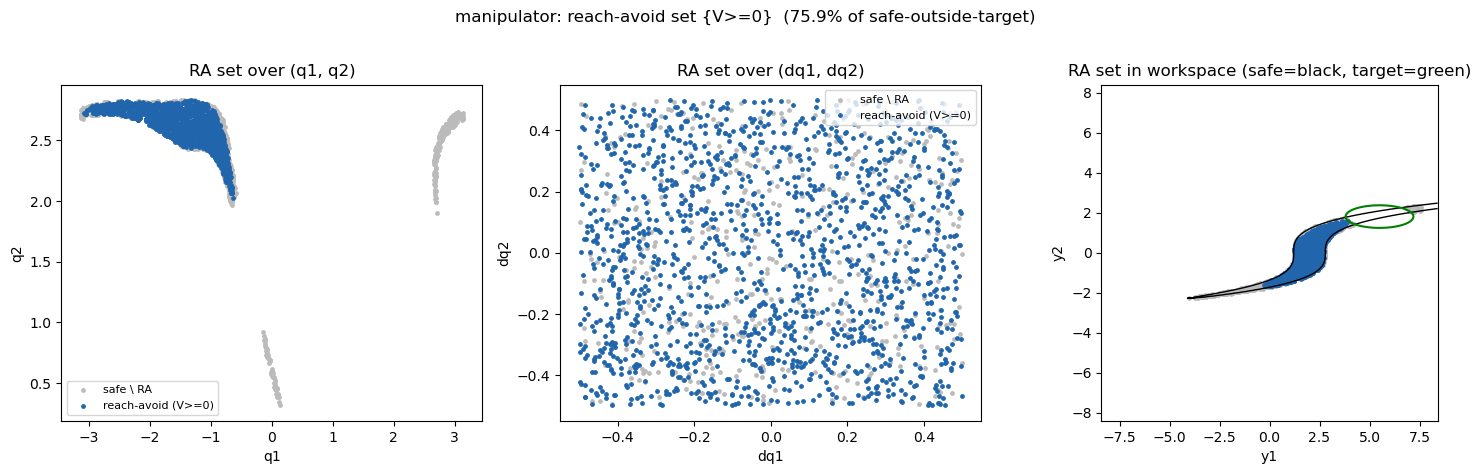

In [10]:
import sympy as sp

N_VIZ = 40_000
Xv = synth_lib.sample_box(LO, HI, N_VIZ, seed=7)
V, safe, target, _ = synth_lib.evaluate(cb, Xv)
cand = (safe >= 0) & (target >= 0)  # safe and outside target
ra = cand & (V >= 0)  # reach-avoid set
Y = np.array(cb["h"](*Xv.T)).reshape(2, -1)  # workspace coords (2, N)
frac = ra.sum() / max(cand.sum(), 1)
print(
    f"reach-avoid set: V>=0 on {ra.sum()} of {cand.sum()} safe-and-outside-target "
    f"samples ({100*frac:.1f}%)"
)

proj = SYS["proj"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (i, jx, lx, ly) in zip(axes[:2], proj):
    ax.scatter(
        Xv[cand & ~ra, i], Xv[cand & ~ra, jx], s=6, c="#bbbbbb", label="safe \\ RA"
    )
    ax.scatter(Xv[ra, i], Xv[ra, jx], s=6, c="#2166ac", label="reach-avoid (V>=0)")
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
    ax.legend(fontsize=8)
    ax.set_title(f"RA set over ({lx}, {ly})")

# workspace panel with safe/target boundaries
ax = axes[2]
ax.scatter(Y[0, cand & ~ra], Y[1, cand & ~ra], s=6, c="#bbbbbb")
ax.scatter(Y[0, ra], Y[1, ra], s=6, c="#2166ac")
y1s, y2s = SYS["y"]
safe_f = sp.lambdify((y1s, y2s), SYS["safe_y"], "numpy")
targ_f = sp.lambdify((y1s, y2s), SYS["target_y"], "numpy")
gy1 = np.linspace(Y[0].min() - 0.5, Y[0].max() + 0.5, 300)
gy2 = np.linspace(Y[1].min() - 0.5, Y[1].max() + 0.5, 300)
GY1, GY2 = np.meshgrid(gy1, gy2)
ax.contour(GY1, GY2, safe_f(GY1, GY2), levels=[0], colors="k", linewidths=1)
ax.contour(GY1, GY2, targ_f(GY1, GY2), levels=[0], colors="g", linewidths=1.5)
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_aspect("equal")
ax.set_title("RA set in workspace (safe=black, target=green)")
fig.suptitle(
    f"{EXAMPLE}: reach-avoid set {{V>=0}}  ({100*frac:.1f}% of safe-outside-target)",
    y=1.02,
)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_ra_set_{EXAMPLE}.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §5 — Closed-form rollout from one reach-avoid sample

Pick a representative start inside the reach-avoid set (input-admissible, far
from the target), integrate $\dot{\bm x}=f+g\,u(\bm x)$ with the exported
control law, and confirm it enters the target while staying safe and within
the per-channel bounds.


rollout start x0 = [-2.4525  2.7499  0.1698  0.2824]  (trial-rollout pick; good on candidate 48 of 1108)
  steps=140  reached=True  stayed_safe=True  stop=reached_target
  max|u_tau1| along trajectory = 676.8  (u_max_eff=679.2)
  max|u_tau2| along trajectory = 298.7  (u_max_eff=500.1)


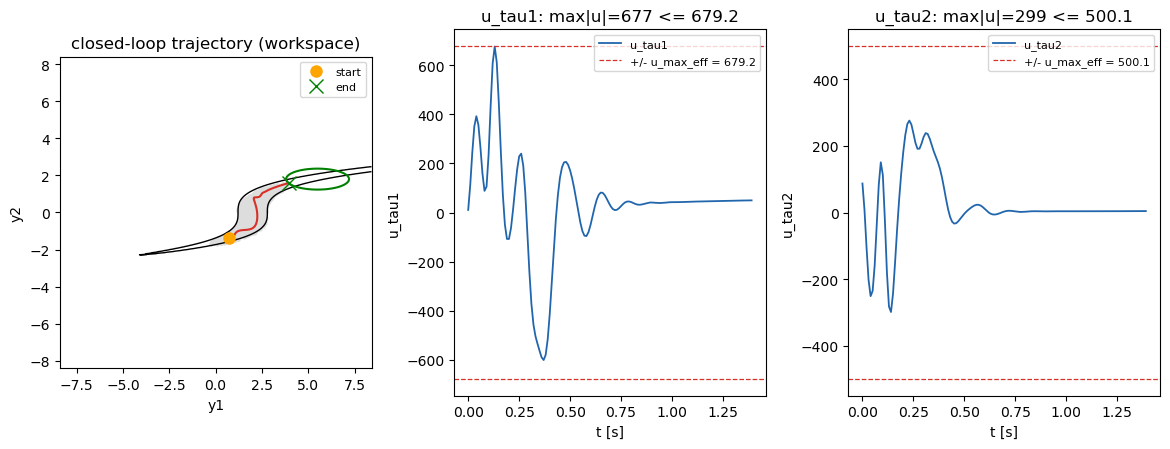

In [11]:
# Start selection by TRIAL ROLLOUT (a good start is one whose *trajectory*
# keeps the FL coordinate bounded -- Dubins v, manipulator sin(q2); a static
# deepest-V / farthest-from-target heuristic cannot see that and often picks a
# start from which the 1/det(A) law saturates). We therefore scan admissible
# reach-avoid candidates, ordered farthest-from-target (informative, long
# trajectory first), and keep the first whose rollout reaches the target while
# staying safe and within u_max_eff.
cand_idx = np.where(ra)[0]
Xs = Xv[cand_idx]
_, _, _, Us = synth_lib.evaluate(cb, Xs)
adm = np.all([np.abs(Us[k]) <= U_MAX_EFF[k] for k in range(len(CHANNELS))], axis=0)
Xa = Xs[adm] if adm.sum() else Xs
tcx, tcy = (5.5, 1.8) if EXAMPLE == "manipulator" else (-1.7, 0.0)
Ya = np.array(cb["h"](*Xa.T)).reshape(2, -1)
order = np.argsort(-((Ya[0] - tcx) ** 2 + (Ya[1] - tcy) ** 2))  # far -> near


def _good(r):
    within = bool(
        np.all(
            [
                r["max_abs_u"][k] <= U_MAX_EFF[k] * (1 + 1e-3)
                for k in range(len(CHANNELS))
            ]
        )
    )
    return bool(r["reached"] and r["stayed_safe"] and within), within


MAX_TRIALS = 300  # cap the search; good starts are common (~25-30%)
x0, sel_trials = None, 0
for _i in order[:MAX_TRIALS]:
    sel_trials += 1
    _r = synth_lib.simulate(SYS, cb, Xa[_i])  # default integrator for the search
    _ok, _ = _good(_r)
    if _ok:
        x0 = Xa[_i]
        break
if x0 is None:
    # no fully-good start found: fall back to the farthest admissible one and
    # let the gate (§6) flag REVIEW so the failure is explicit, not hidden.
    x0 = Xa[order[0]]
    print(
        f"WARNING: no good rollout among {sel_trials} candidates; "
        f"using farthest admissible start (rollout will be flagged in §6)."
    )
else:
    print(
        f"rollout start x0 = {np.round(x0, 4)}  "
        f"(trial-rollout pick; good on candidate {sel_trials} of {len(order)})"
    )

res = synth_lib.simulate(SYS, cb, x0)
X = res["X"]
Yt = np.array(cb["h"](*X.T)).reshape(2, -1)
print(
    f"  steps={len(res['t'])}  reached={res['reached']}  stayed_safe={res['stayed_safe']}  "
    f"stop={res['stop_reason']}"
)
for k, ch in enumerate(CHANNELS):
    print(
        f"  max|u_{ch}| along trajectory = {res['max_abs_u'][k]:.4g}  (u_max_eff={U_MAX_EFF[k]:.4g})"
    )

# workspace trajectory + ONE control subplot PER CHANNEL (the channels have
# different effective bounds, e.g. Dubins omega/a = 7.7/5.1, manipulator
# tau1/tau2 ~ 679/500, so a shared axis with a single bound is misleading).
m = len(CHANNELS)
fig, axes = plt.subplots(1, 1 + m, figsize=(5.0 + 3.4 * m, 4.6))
ax = axes[0]
ax.scatter(Y[0, ra], Y[1, ra], s=4, c="#dddddd")
ax.contour(GY1, GY2, safe_f(GY1, GY2), levels=[0], colors="k", linewidths=1)
ax.contour(GY1, GY2, targ_f(GY1, GY2), levels=[0], colors="g", linewidths=1.5)
ax.plot(Yt[0], Yt[1], "-", c="#d73027", lw=1.5)
ax.plot(Yt[0, 0], Yt[1, 0], "o", c="orange", ms=8, label="start")
ax.plot(Yt[0, -1], Yt[1, -1], "x", c="green", ms=10, label="end")
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("closed-loop trajectory (workspace)")

for k, ch in enumerate(CHANNELS):
    ax = axes[1 + k]
    ax.plot(res["t"], res["U"][k], c="#2166ac", lw=1.3, label=f"u_{ch}")
    ax.axhline(
        U_MAX_EFF[k],
        color="#d73027",
        ls="--",
        lw=0.9,
        label=f"+/- u_max_eff = {U_MAX_EFF[k]:g}",
    )
    ax.axhline(-U_MAX_EFF[k], color="#d73027", ls="--", lw=0.9)
    peak = float(res["max_abs_u"][k])
    ok = peak <= U_MAX_EFF[k] * (1 + 1e-3)
    ax.set_xlabel("t [s]")
    ax.set_ylabel(f"u_{ch}")
    ax.legend(fontsize=8)
    ax.set_title(f"u_{ch}: max|u|={peak:.3g} {'<=' if ok else '>'} {U_MAX_EFF[k]:g}")
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_rollout_{EXAMPLE}.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §5b — Constrained vs. unconstrained from the same start

Both controllers share the same backstepping certificate at the same
$(\mu,\lambda)$; the only difference is that the constrained one was solved
with hard per-sample input limits while the unconstrained vanilla-$k_1$
baseline ignores them. Rolling both out from the SAME start $x_0$ shows the
trade-off: the unconstrained law typically reaches faster but with much larger
$|u_i|$, while the constrained law respects (or is closer to) $u_{\max}^{\rm eff}$.


constrained vs unconstrained from the same x0 = [-2.4525  2.7499  0.1698  0.2824]
  constrained  : reached=True safe=True stop=reached_target  |u_tau1|<=677, |u_tau2|<=299
  unconstrained: reached=True safe=True stop=reached_target  |u_tau1|<=1.75e+03, |u_tau2|<=205


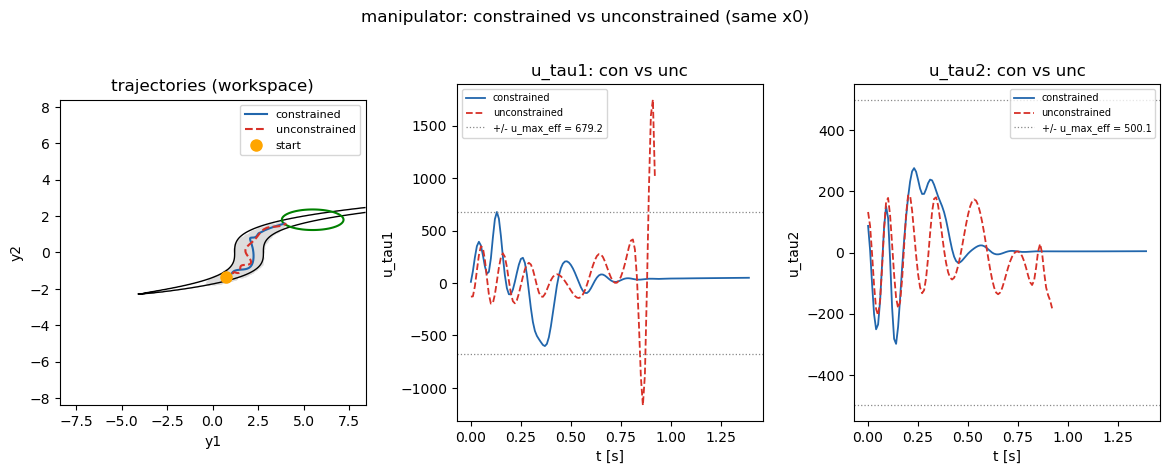

In [12]:
res_unc = synth_lib.simulate(SYS, cb_unc, x0)
print("constrained vs unconstrained from the same x0 =", np.round(x0, 4))
for tag, r in [("constrained", res), ("unconstrained", res_unc)]:
    mu_str = ", ".join(
        f"|u_{ch}|<={r['max_abs_u'][k]:.3g}" for k, ch in enumerate(CHANNELS)
    )
    print(
        f"  {tag:13s}: reached={r['reached']} safe={r['stayed_safe']} "
        f"stop={r['stop_reason']:>14s}  {mu_str}"
    )

Yc = np.array(cb["h"](*res["X"].T)).reshape(2, -1)
Yu = np.array(cb_unc["h"](*res_unc["X"].T)).reshape(2, -1)
m = len(CHANNELS)
fig, axes = plt.subplots(1, 1 + m, figsize=(5.0 + 3.4 * m, 4.6))
ax = axes[0]
ax.scatter(Y[0, ra], Y[1, ra], s=4, c="#dddddd")
ax.contour(GY1, GY2, safe_f(GY1, GY2), levels=[0], colors="k", linewidths=1)
ax.contour(GY1, GY2, targ_f(GY1, GY2), levels=[0], colors="g", linewidths=1.5)
ax.plot(Yc[0], Yc[1], "-", c="#2166ac", lw=1.5, label="constrained")
ax.plot(Yu[0], Yu[1], "--", c="#d73027", lw=1.5, label="unconstrained")
ax.plot(Yc[0, 0], Yc[1, 0], "o", c="orange", ms=8, label="start")
ax.set_xlabel("y1")
ax.set_ylabel("y2")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("trajectories (workspace)")
for k, ch in enumerate(CHANNELS):
    ax = axes[1 + k]
    ax.plot(res["t"], res["U"][k], "-", c="#2166ac", lw=1.3, label="constrained")
    ax.plot(
        res_unc["t"], res_unc["U"][k], "--", c="#d73027", lw=1.3, label="unconstrained"
    )
    ax.axhline(
        U_MAX_EFF[k],
        color="#888888",
        ls=":",
        lw=0.9,
        label=f"+/- u_max_eff = {U_MAX_EFF[k]:g}",
    )
    ax.axhline(-U_MAX_EFF[k], color="#888888", ls=":", lw=0.9)
    ax.set_xlabel("t [s]")
    ax.set_ylabel(f"u_{ch}")
    ax.legend(fontsize=7)
    ax.set_title(f"u_{ch}: con vs unc")
fig.suptitle(f"{EXAMPLE}: constrained vs unconstrained (same x0)", y=1.02)
fig.tight_layout()
fig.savefig(
    os.path.join(REV_DATA, f"phase1_3_compare_{EXAMPLE}.png"),
    dpi=130,
    bbox_inches="tight",
)
plt.show()

## §6 — Export Phase 1.3 outputs


In [13]:
within_bounds = bool(
    np.all(
        [res["max_abs_u"][k] <= U_MAX_EFF[k] * (1 + 1e-3) for k in range(len(CHANNELS))]
    )
)
rollout_ok = bool(res["reached"] and res["stayed_safe"] and within_bounds)
# Verdict requires BOTH the dense bound gate (§3) and a clean rollout (§5).
verdict = "PASS" if (bound_realized and rollout_ok) else "REVIEW"
out = {
    "phase": "1.3",
    "example": EXAMPLE,
    "controller_constrained_py": os.path.relpath(con_path, ROOT),
    "controller_unconstrained_py": os.path.relpath(unc_path, ROOT),
    "u_max_eff": dict(zip(CHANNELS, U_MAX_EFF)),
    "bound_realized": bool(bound_realized),
    "ra_fraction_of_safe_outside_target": float(frac),
    "rollout": {
        "x0": [float(v) for v in x0],
        "reached": bool(res["reached"]),
        "stayed_safe": bool(res["stayed_safe"]),
        "within_bounds": within_bounds,
        "stop_reason": res["stop_reason"],
        "max_abs_u": {ch: float(res["max_abs_u"][k]) for k, ch in enumerate(CHANNELS)},
    },
    "verdict": verdict,
    "unconstrained_rollout": {
        "reached": bool(res_unc["reached"]),
        "stayed_safe": bool(res_unc["stayed_safe"]),
        "max_abs_u": {
            ch: float(res_unc["max_abs_u"][k]) for k, ch in enumerate(CHANNELS)
        },
    },
    "notes": (
        "Phase 1.3 synthesizes BOTH a constrained hard-SOP controller and an "
        "unconstrained vanilla-k1 baseline at the same settings. The bound gate + rollout "
        "verdict refer to the constrained controller; the unconstrained one is the "
        "comparison baseline. The constrained .py + u_max_eff + X_S_eff box are the "
        "Phase 2 interface."
    ),
}
out_path = os.path.join(REV_DATA, f"phase1_3_outputs_{EXAMPLE}.json")
with open(out_path, "w") as fh:
    json.dump(out, fh, indent=2)
print(f"wrote {out_path}")
print(json.dumps(out, indent=2))

wrote /Users/jianqiang/Downloads/reach_avoid_backstepping_MPC/revision/data/phase1_3_outputs_manipulator.json
{
  "phase": "1.3",
  "example": "manipulator",
  "controller_constrained_py": "revision/controllers/manipulator_constrained.py",
  "controller_unconstrained_py": "revision/controllers/manipulator_unconstrained.py",
  "u_max_eff": {
    "tau1": 679.2,
    "tau2": 500.1
  },
  "bound_realized": false,
  "ra_fraction_of_safe_outside_target": 0.7588357588357588,
  "rollout": {
    "x0": [
      -2.4524861804964635,
      2.749872782055109,
      0.16981715452584678,
      0.2824420104227454
    ],
    "reached": true,
    "stayed_safe": true,
    "within_bounds": true,
    "stop_reason": "reached_target",
    "max_abs_u": {
      "tau1": 676.7837040522322,
      "tau2": 298.7135939859159
    }
  },
  "verdict": "REVIEW",
  "unconstrained_rollout": {
    "reached": true,
    "stayed_safe": true,
    "max_abs_u": {
      "tau1": 1747.8232783947226,
      "tau2": 205.39246054896938
 